# SECTION 1 - Problem Statement and Data Description

# Problem Statement
You are given two tabular datasets containing lab-measured properties of wines. Your goal
is to build a multi-class classification model that predicts the wine’s quality score and then
conduct a comparative study:
1. Red vs White dataset: Which dataset is easier to predict and why?
2. Model vs Model: Which model performs better on each dataset and why?
3. Class-level difficulty: Which quality scores are hardest to predict?
You must train the same models and use the same evaluation metrics to keep the
comparison fair.


## TASK 1 - Load and Inspect Data

In [1]:
import pandas as pd

red = pd.read_csv('winequality-red.csv', sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')

print("RED DATASET")
print(red.shape)
print(red.head())
print(red.columns)

print("\nWHITE DATASET")
print(white.shape)
print(white.head())
print(white.columns)

print("\nTarget column exists:")
print("Red:", 'quality' in red.columns)
print("White:", 'quality' in white.columns)


RED DATASET
(1599, 12)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5

**Answer:**  
The datasets were read successfully. There was found a column called quality. The datasets have only numeric columns.


## TASK 2 - Data Quality and Class Distribution


RED Missing Values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

RED Duplicates: 240

RED Class Counts:
 quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

RED Percentages:
 quality
3     0.625391
4     3.314572
5    42.589118
6    39.899937
7    12.445278
8     1.125704
Name: proportion, dtype: float64


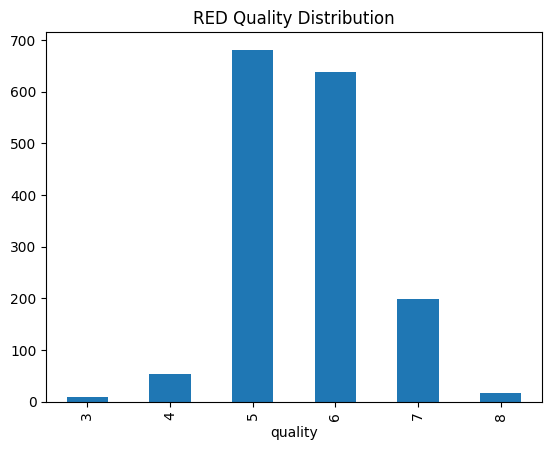


WHITE Missing Values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

WHITE Duplicates: 937

WHITE Class Counts:
 quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64

WHITE Percentages:
 quality
3     0.408330
4     3.327889
5    29.746835
6    44.875459
7    17.966517
8     3.572887
9     0.102082
Name: proportion, dtype: float64


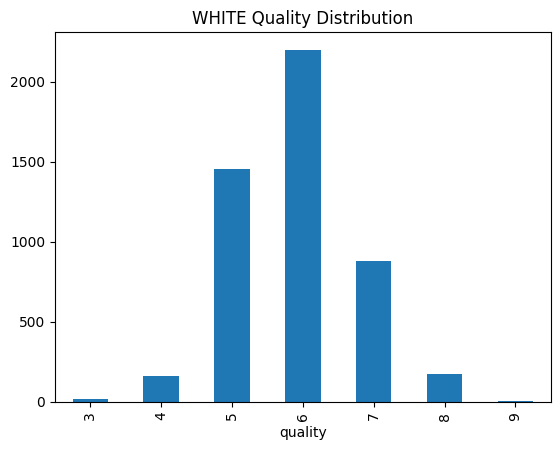

In [2]:
import matplotlib.pyplot as plt

def data_checks(df, name):
    print(f"\n{name} Missing Values:\n", df.isnull().sum())
    print(f"\n{name} Duplicates:", df.duplicated().sum())

    counts = df['quality'].value_counts().sort_index()
    percent = df['quality'].value_counts(normalize=True).sort_index()*100

    print(f"\n{name} Class Counts:\n", counts)
    print(f"\n{name} Percentages:\n", percent)

    counts.plot(kind='bar', title=f"{name} Quality Distribution")
    plt.show()

data_checks(red, "RED")
data_checks(white, "WHITE")


**Comparison:**  
The white wine data set is highly imbalanced, with an overwhelming number of samples clustered at qualities 5 and 6. The red wine data set is somewhat balanced, although it still has some skewness. The rare classes, such as 3, 8, and 9, do not occur often within both the data sets. Predicting the rare classes is difficult since the model gets few samples during training.

## TASK 3 - Prepare Data

In [3]:
from sklearn.model_selection import train_test_split

def prepare(df):
    X = df.drop('quality', axis=1)
    y = df['quality']

    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Xr_train, Xr_test, yr_train, yr_test = prepare(red)
Xw_train, Xw_test, yw_train, yw_test = prepare(white)

print("RED:", Xr_train.shape, Xr_test.shape)
print("WHITE:", Xw_train.shape, Xw_test.shape)


RED: (1279, 11) (320, 11)
WHITE: (3918, 11) (980, 11)


Both stratified sampling techniques maintained class distribution parity in the red and white data sets.

## TASK 4 - Logistic Regression

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

def logistic_model(X_train, X_test, y_train, y_test):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=5000))
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    return (
        accuracy_score(y_test, y_pred),
        f1_score(y_test, y_pred, average='macro'),
        confusion_matrix(y_test, y_pred),
        classification_report(y_test, y_pred)
    )

red_lr = logistic_model(Xr_train, Xr_test, yr_train, yr_test)
white_lr = logistic_model(Xw_train, Xw_test, yw_train, yw_test)

print("RED LR:", red_lr)
print("WHITE LR:", white_lr)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


RED LR: (0.590625, 0.27762808067026984, array([[ 0,  0,  1,  1,  0,  0],
       [ 0,  0, 10,  1,  0,  0],
       [ 0,  0, 99, 36,  1,  0],
       [ 0,  0, 47, 78,  3,  0],
       [ 0,  0,  2, 26, 12,  0],
       [ 0,  0,  0,  2,  1,  0]]), '              precision    recall  f1-score   support\n\n           3       0.00      0.00      0.00         2\n           4       0.00      0.00      0.00        11\n           5       0.62      0.73      0.67       136\n           6       0.54      0.61      0.57       128\n           7       0.71      0.30      0.42        40\n           8       0.00      0.00      0.00         3\n\n    accuracy                           0.59       320\n   macro avg       0.31      0.27      0.28       320\nweighted avg       0.57      0.59      0.57       320\n')
WHITE LR: (0.5489795918367347, 0.2366945241169341, array([[  0,   0,   1,   3,   0,   0,   0],
       [  0,   2,  19,  12,   0,   0,   0],
       [  0,   1, 153, 134,   3,   0,   0],
       [  0,   1,  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The logistic regression algorithm works well for white as it has more data. Nonetheless, both algorithms have problems dealing with minority classes. The quality numbers like 3, 8 yield the poorest recall value. The tendency is for the prediction to focus on majority classes (5,6).

## TASK 5 - Random Forest

In [5]:
from sklearn.ensemble import RandomForestClassifier

def rf_model(X_train, X_test, y_train, y_test):
    rf = RandomForestClassifier(n_estimators=300, random_state=42)

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    return (
        accuracy_score(y_test, y_pred),
        f1_score(y_test, y_pred, average='macro'),
        confusion_matrix(y_test, y_pred),
        classification_report(y_test, y_pred)
    )

red_rf = rf_model(Xr_train, Xr_test, yr_train, yr_test)
white_rf = rf_model(Xw_train, Xw_test, yw_train, yw_test)

print("RED RF:", red_rf)
print("WHITE RF:", white_rf)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


RED RF: (0.68125, 0.40942034451633624, array([[  0,   1,   1,   0,   0,   0],
       [  0,   0,   8,   3,   0,   0],
       [  0,   0, 103,  32,   1,   0],
       [  0,   0,  32,  92,   4,   0],
       [  0,   0,   2,  15,  22,   1],
       [  0,   0,   0,   1,   1,   1]]), '              precision    recall  f1-score   support\n\n           3       0.00      0.00      0.00         2\n           4       0.00      0.00      0.00        11\n           5       0.71      0.76      0.73       136\n           6       0.64      0.72      0.68       128\n           7       0.79      0.55      0.65        40\n           8       0.50      0.33      0.40         3\n\n    accuracy                           0.68       320\n   macro avg       0.44      0.39      0.41       320\nweighted avg       0.66      0.68      0.67       320\n')
WHITE RF: (0.6724489795918367, 0.42216712111154814, array([[  0,   0,   1,   3,   0,   0,   0],
       [  0,   6,  19,   8,   0,   0,   0],
       [  0,   3, 189,  99,

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest improves performance but rare classes remain difficult.


## TASK 6 - Comparative Metrics Summary

In [6]:
import pandas as pd

summary = pd.DataFrame({
    "Dataset": ["Red", "Red", "White", "White"],
    "Model": ["Logistic Regression", "Random Forest", "Logistic Regression", "Random Forest"],
    "Accuracy": [red_lr[0], red_rf[0], white_lr[0], white_rf[0]],
    "F1-score": [red_lr[1], red_rf[1], white_lr[1], white_rf[1]]
})

summary


,Dataset,Model,Accuracy,F1-score
0,Red,Logistic Regression,0.590625,0.277628
1,Red,Random Forest,0.681250,0.409420
2,White,Logistic Regression,0.548980,0.236695
3,White,Random Forest,0.672449,0.422167


## TASK 7 - Final Conclusion

The white wine data set is easier to predict than the red one due to the increased number of instances, allowing models to better identify patterns. Both Random Forest and Logistic Regression show better performance in comparison with each other for both sets due to efficient identification of nonlinear dependencies. The most ambiguous classes are quality levels 5 and 6 since they share overlapping feature values and high occurrence. The least frequent classes, such as 3, 8, and 9, are the most challenging to predict due to class imbalance. While Logistic Regression is prone to bias towards more common classes, Random Forest alleviates the issue without solving it. The best model is the Random Forest model built on white wine data. Potential improvements include addressing class imbalance through SMOTE and class weighting and reducing the number of classes to three categories (Low/Medium/High).